In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
accuracy_score, precision_score,
recall_score, f1_score,
confusion_matrix, classification_report,
roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')
print("Libraries imported!")

Libraries imported!


In [2]:
X_train = np.load('saved_models/X_train_w2v.npy')
X_test = np.load('saved_models/X_test_w2v.npy')
y_train = np.load('saved_models/y_train.npy')
y_test = np.load('saved_models/y_test.npy')
print("Data loaded!")
print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

Data loaded!
X_train: (35378, 100)
X_test : (8845, 100)
y_train: (35378,)
y_test : (8845,)


In [3]:
print("Training Random Forest... please wait...")
rf_model = RandomForestClassifier(
n_estimators=200,
max_depth=None,
random_state=42,
n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest trained!")

Training Random Forest... please wait...
Random Forest trained!


In [5]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
print("Predictions made!")
print(f"\nSample predictions (first 10):")
print(f"Predicted : {y_pred[:10]}")
print(f"Actual    : {y_test[:10].astype(int)}")

Predictions made!

Sample predictions (first 10):
Predicted : [0 0 0 0 1 0 0 0 1 0]
Actual    : [0 0 0 0 1 0 0 0 1 0]


In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print("=" * 50)
print(" RANDOM FOREST — EVALUATION RESULTS")
print("=" * 50)
print(f" Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision : {precision:.4f}")
print(f" Recall : {recall:.4f}")
print(f" F1-Score : {f1:.4f}")
print(f" ROC-AUC : {roc_auc:.4f}")
print("=" * 50)
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
target_names=['Fake','Real']))

 RANDOM FOREST — EVALUATION RESULTS
 Accuracy : 0.9678 (96.78%)
 Precision : 0.9699
 Recall : 0.9633
 F1-Score : 0.9666
 ROC-AUC : 0.9954

Detailed Report:
              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97      4562
        Real       0.97      0.96      0.97      4283

    accuracy                           0.97      8845
   macro avg       0.97      0.97      0.97      8845
weighted avg       0.97      0.97      0.97      8845



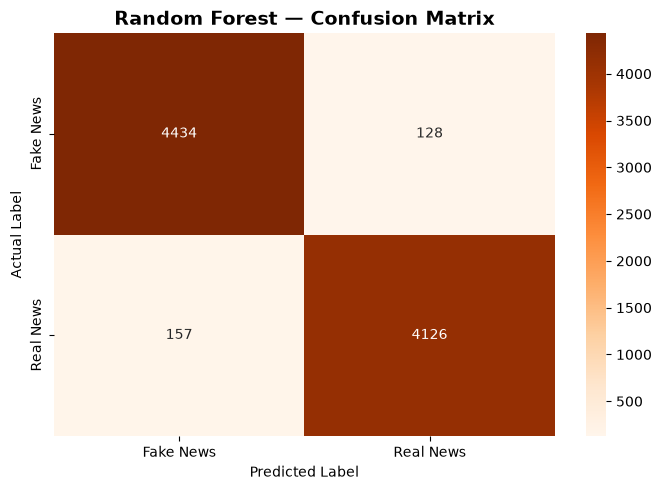

True Positives : 4,126
True Negatives : 4,434
False Positives : 128
False Negatives : 157


In [7]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
cmap='Oranges',
xticklabels=['Fake News', 'Real News'],
yticklabels=['Fake News', 'Real News'])
plt.title('Random Forest — Confusion Matrix',
fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150)
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"True Positives : {tp:,}")
print(f"True Negatives : {tn:,}")
print(f"False Positives : {fp:,}")
print(f"False Negatives : {fn:,}")

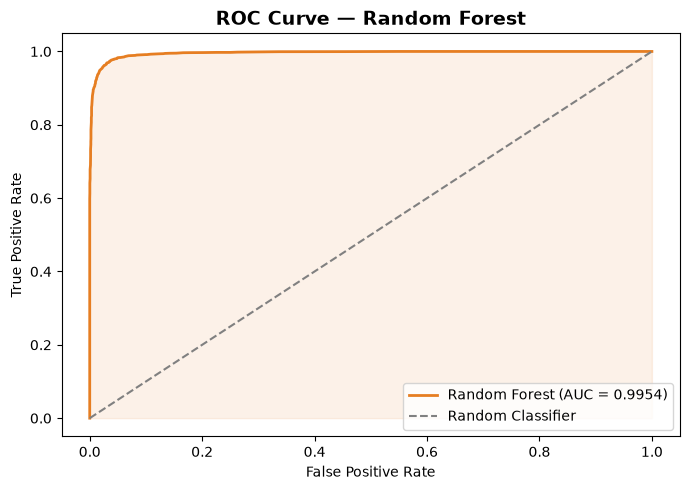

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#e67e22', linewidth=2,
label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray',
linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e67e22')
plt.title('ROC Curve — Random Forest',
fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('rf_roc_curve.png', dpi=150)
plt.show()

In [9]:
print("ROC Curve saved!")

ROC Curve saved!


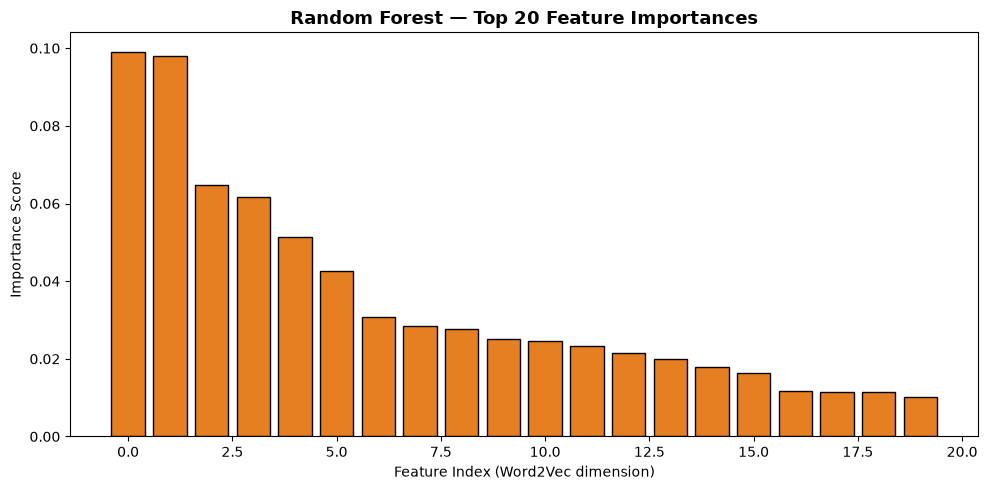

Feature importance chart saved!


In [10]:
importances = rf_model.feature_importances_
top_idx = importances.argsort()[-20:][::-1]
plt.figure(figsize=(10, 5))
plt.bar(range(20), importances[top_idx],
color='#e67e22', edgecolor='black')
plt.title('Random Forest — Top 20 Feature Importances',
fontsize=13, fontweight='bold')
plt.xlabel('Feature Index (Word2Vec dimension)')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")


In [12]:
import pickle, os

os.makedirs('saved_models', exist_ok=True)
pickle.dump(rf_model, open('saved_models/rf_model.pkl', 'wb'))
print("Random Forest model saved!")
print("\nFiles in saved_models/:")

# Indented block inside loop:
for f in os.listdir('saved_models'):
    print(f"  {f}")

Random Forest model saved!

Files in saved_models/:
  rf_model.pkl
  word2vec.model
  word2vec.model.syn1neg.npy
  word2vec.model.wv.vectors.npy
  X_test_w2v.npy
  X_train_w2v.npy
  y_test.npy
  y_train.npy


In [13]:
print("=" * 55)
print(" ML MODEL SUMMARY — Random Forest (Eshan)")
print("=" * 55)
print(f"""
Algorithm : Random Forest
Feature Input : Word2Vec (100 dimensions)
N Estimators : 200 trees
Training Size : {X_train.shape[0]:,} samples
Testing Size : {X_test.shape[0]:,} samples
Accuracy : {accuracy*100:.2f}%
Precision : {precision:.4f}
Recall : {recall:.4f}
F1-Score : {f1:.4f}
ROC-AUC : {roc_auc:.4f}
Saved Files:
rf_model.pkl
rf_confusion_matrix.png
rf_roc_curve.png
rf_feature_importance.png
""")


 ML MODEL SUMMARY — Random Forest (Eshan)

Algorithm : Random Forest
Feature Input : Word2Vec (100 dimensions)
N Estimators : 200 trees
Training Size : 35,378 samples
Testing Size : 8,845 samples
Accuracy : 96.78%
Precision : 0.9699
Recall : 0.9633
F1-Score : 0.9666
ROC-AUC : 0.9954
Saved Files:
rf_model.pkl
rf_confusion_matrix.png
rf_roc_curve.png
rf_feature_importance.png

